Running Multi-State Simulations: 100%|██████████| 10000/10000 [00:27<00:00, 361.03it/s]


Analytic EL: £98.37344178595767m
Simulated EL: £99.67105498590637m
VaR (99%): £395.5390124767908m
VaR (95%): £256.9828494844205m
Expected Shortfall (99%): 497.56444234453744m


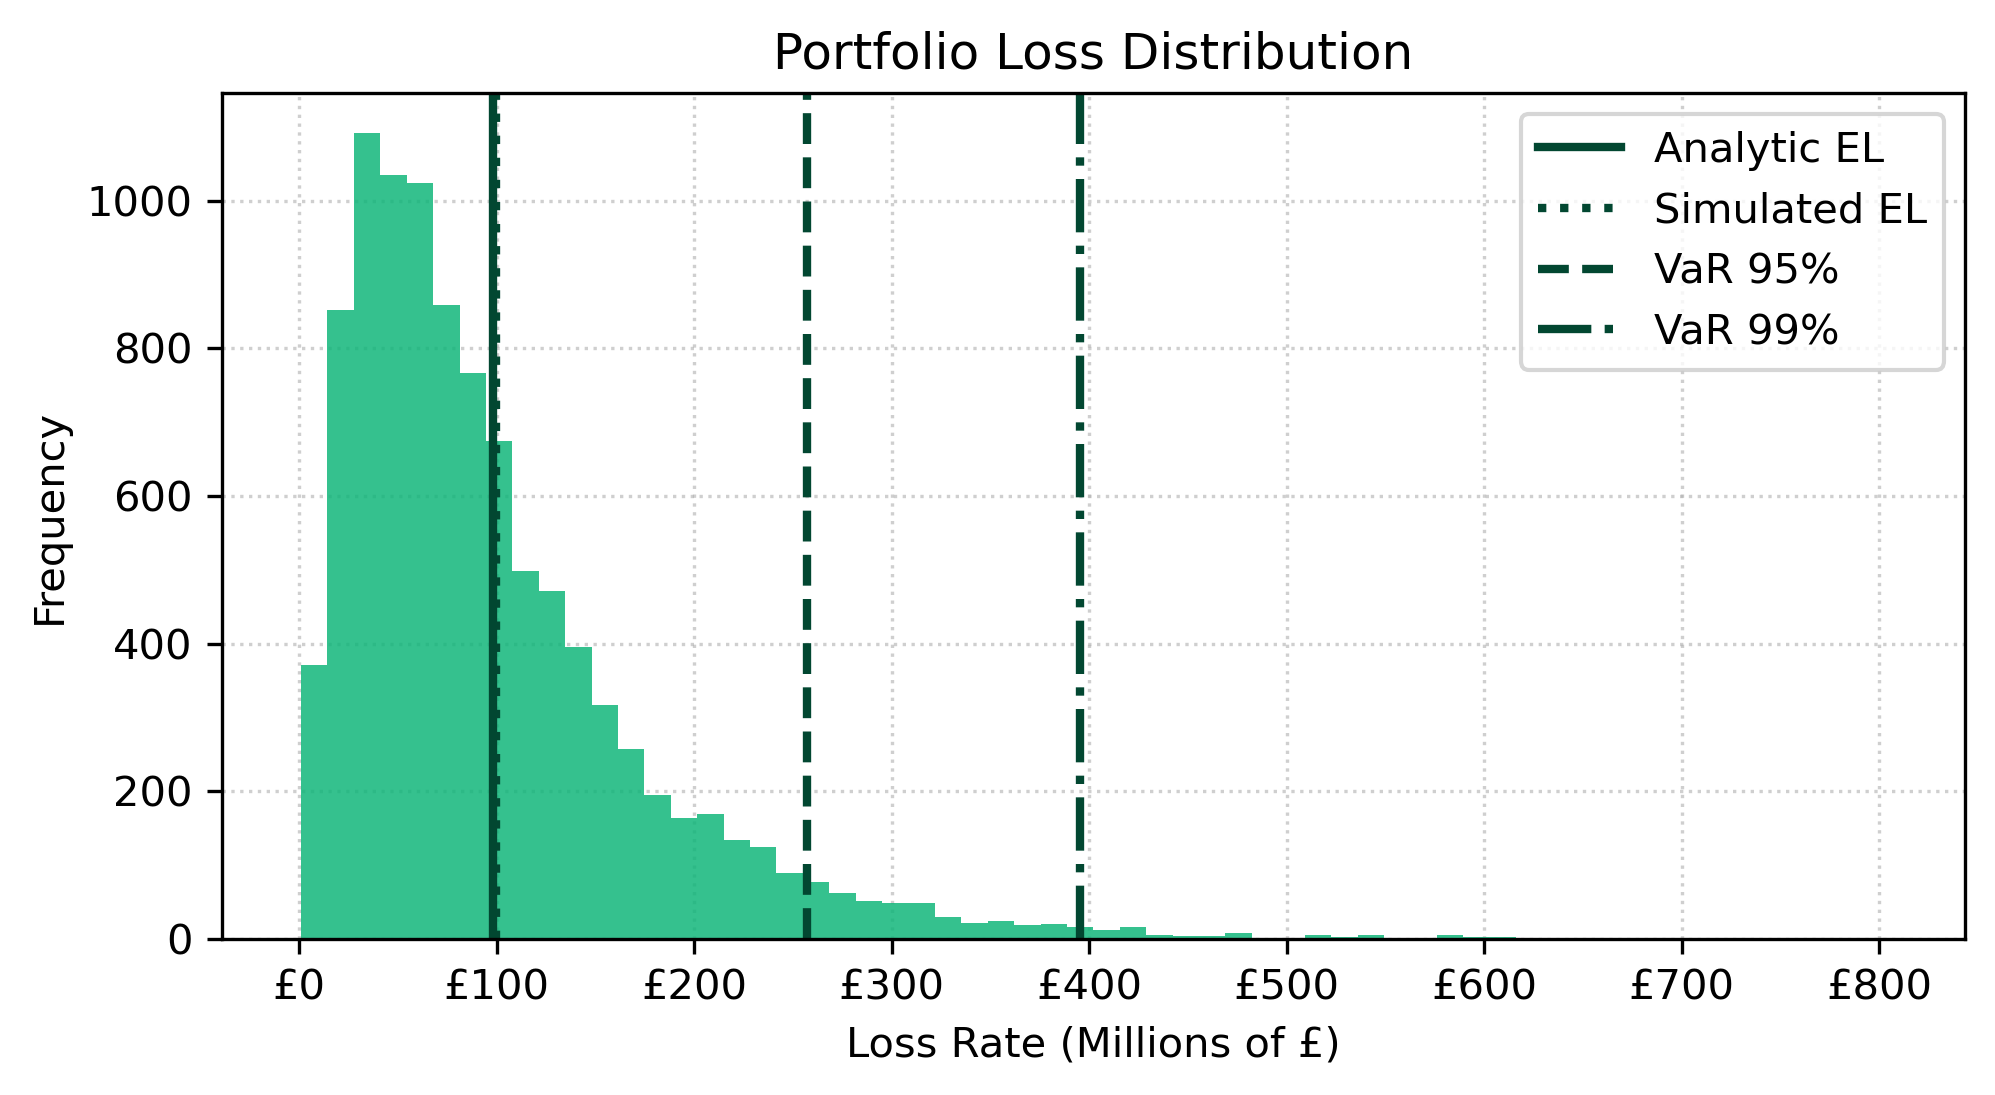

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from tqdm import tqdm

everyday_green = '#11B67A'
racing_green = '#024731'
heritage_green = '#006A4D'

class MultiStateSimulator:

    def __init__(self):
        self.portfolio_df = None
        self.cov = None
        self.C = None
        self.losses = None
        self.tm_df = None
        self.states = None

    def _make_pd(self, cov, eps=1e-8):
        cov = (cov + cov.T) / 2
        lam_min = np.linalg.eigvalsh(cov).min()
        delta = max(0.0, -lam_min + eps)
        return cov + delta * np.eye(cov.shape[0])
    
    def _chol_from_cov(self, cov, eps=1e-8):
        cov_pd = self._make_pd(cov, eps=eps)
        C = np.linalg.cholesky(cov_pd)
        return cov_pd, C
    
    def _prep_inputs(self, loan_book):
        EAD = loan_book['ead'].to_numpy()
        LGD = loan_book['lgd'].to_numpy()
        PD = loan_book['pd'].to_numpy()
        RSQ = loan_book['rsq'].to_numpy()
        ratings = loan_book['credit_rating'].to_list()
        return EAD, LGD, PD, RSQ, ratings
    
    def _compute_multi_state_thresholds(self, tm_df, eps=1e-12):
        """
        Converts a transition matrix into sequential normal distribution cut-offs
        by taking the cumulative sum of probabilities from worst (Default) to best (AAA).
        """
        self.states = list(tm_df.columns)
        # Reorder columns to ensure Default is the baseline left-hand boundary
        ordered_states = ['Default'] + [s for s in self.states if s != 'Default'][::-1]
        tm_ordered = tm_df[ordered_states]
        
        # Compute cumulative probabilities per row
        cum_probs = tm_ordered.cumsum(axis=1)
        
        # Map cumulative probabilities to standard normal coordinates
        # Clip to protect against log/norm infinity errors at 0.0 or 1.0 bounds
        cum_probs_clipped = np.clip(cum_probs.to_numpy(), eps, 1.0 - eps)
        thresholds_matrix = norm.ppf(cum_probs_clipped)
        
        # Store as a dictionary mapping a rating string to its vector of normal limits
        threshold_lookup = {rating: thresholds_matrix[i, :] for i, rating in enumerate(tm_df.index)}
        return ordered_states, threshold_lookup
        

    def simulate_losses(
        self,
        portfolio_df,
        factor_index,
        cov,
        tm_df,
        n_scenarios=100_000,
        chunk=1_000,
        seed=42,
        eps_pd=1e-8
    ):
        self.portfolio_df = portfolio_df.reset_index(drop=True)
        self.cov, self.C = self._chol_from_cov(np.asarray(cov, float), eps=eps_pd)
        self.tm_df = tm_df
        C = self.C

        M = len(self.portfolio_df)
        N = len(factor_index)

        # 1. Map out the hierarchical multi-state thresholds
        ordered_states, threshold_lookup = self._compute_multi_state_thresholds(tm_df)
        default_state_idx = ordered_states.index('Default')

        # 2. Extract asset parameter frameworks
        EAD, LGD, PD, RSQ, ratings = self._prep_inputs(self.portfolio_df)
        sqrt_rsq = np.sqrt(np.clip(RSQ, 0.0, 1.0))[:, None]
        weight = (LGD * EAD)[:, None]

        # Build an (M, State_Count) matrix of thresholds specific to each asset's starting rating
        asset_thresholds = np.array([threshold_lookup[r] for r in ratings]) # Shape: (M, States)

        FC_hat = self._build_factor_loadings(factor_index, M, N, C)
        rng = np.random.default_rng(seed)
        losses_out = np.empty(n_scenarios)
        filled = 0

        with tqdm(total=n_scenarios, desc='Running Multi-State Simulations') as pbar:
            while filled < n_scenarios:
                s = min(chunk, n_scenarios - filled)
                sl = slice(filled, filled + s)

                Z = rng.standard_normal(size=(N, s))
                Y = FC_hat @ Z
                Xi = rng.standard_normal(size=(M, s))
                X = sqrt_rsq * Y + np.sqrt(1.0 - sqrt_rsq ** 2) * Xi # Shape: (M, s)

                # 3. Determine destination states across scenarios
                # We broadcast the (M, s) returns against the (M, States) bounds
                # 'np.searchsorted' maps out which discrete bin index the return falls into
                defaults = np.zeros((M, s), dtype=bool)
                
                for asset_idx in range(M):
                    # Find where each scenario's asset return lands relative to the thresholds
                    bin_indices = np.digitize(X[asset_idx, :], asset_thresholds[asset_idx, :])
                    # If bin_indices == 0, the asset fell below the first threshold (Default)
                    defaults[asset_idx, :] = (bin_indices == default_state_idx)

                losses_out[sl] = (defaults * weight).sum(axis=0)

                filled += s
                pbar.update(s)
        
        self.losses = pd.Series(losses_out)
        return self.losses

    def _build_factor_loadings(self, factor_index, M, N, C):
        F = np.zeros((M, N), dtype=float)
        for i, (_, row) in enumerate(self.portfolio_df[['region', 'sector']].iterrows()):
            r, s = row['region'], row['sector']
            F[i, factor_index[r]] = 1.0
            F[i, factor_index[s]] = 1.0

        FC = F @ C
        row_norms = np.linalg.norm(FC, axis=1, keepdims=True)
        FC_hat = FC / row_norms
        return FC_hat

    def analytic_EL(self):
        EAD, LGD, PD, _, _ = self._prep_inputs(self.portfolio_df)
        return float(np.sum(PD * LGD * EAD))
    
    def var_quantile(self, alpha=0.99):
        return float(np.quantile(self.losses.to_numpy(), alpha))
    
    def expected_shortfall(self, alpha=0.99):
        arr = self.losses.to_numpy()
        q = np.quantile(arr, alpha)
        tail = arr[arr >= q]
        return float(tail.mean()) if len(tail) > 0 else float(q)
    
    def plot_loss_distribution(self):
        """Generates a portfolio loss distribution histogram overlaying your baseline parameters."""
        arr = self.losses.to_numpy()
        denom = 1e6

        fig, ax = plt.subplots(figsize=(6.75, 3.75), dpi=300)
        ax.hist(arr / denom, bins=60, color=everyday_green, edgecolor=None, alpha=0.85)

        ax.axvline(self.analytic_EL() / denom, color=racing_green, lw=2, label='Analytic EL')
        ax.axvline(arr.mean() / denom, color=racing_green, lw=2, ls=':', label='Simulated EL')
        ax.axvline(self.var_quantile(0.95) / denom, color=racing_green, lw=2, ls='--', label='VaR 95%')
        ax.axvline(self.var_quantile(0.99) / denom, color=racing_green, lw=2, ls='-.', label='VaR 99%')

        ax.set_title('Portfolio Loss Distribution')
        ax.set_xlabel('Loss Rate (Millions of £)')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('£{x:,.0f}'))
        fig.tight_layout()
        return fig

    # Load assets and macro frameworks
systematic_shocks = pd.read_csv('systematic_shocks.csv', index_col='Quarter')
cov = systematic_shocks.cov()
portfolio = pd.read_csv('loan_book.csv')
pd_mapping = pd.read_csv('pd_mapping.csv')

# Load the transition matrix 
tm_df = pd.read_csv('transition_matrix.csv', index_col='From/To')

portfolio = pd.merge(portfolio, pd_mapping, left_on='credit_rating', right_on='Credit Rating')
factors = list(cov.columns)
factor_index = {name: j for j, name in enumerate(factors)}

# Initialize and run the multi-state model
sim = MultiStateSimulator()
losses = sim.simulate_losses(
    portfolio,
    factor_index,
    cov,
    tm_df=tm_df,
    n_scenarios=10000
)

# Output results
fig = sim.plot_loss_distribution()

print(f"Analytic EL: £{sim.analytic_EL()/1e6}m")
print(f"Simulated EL: £{sim.losses.mean()/1e6}m")
print(f"VaR (99%): £{sim.var_quantile(0.99)/1e6}m")
print(f"VaR (95%): £{sim.var_quantile(0.95)/1e6}m")
print(f"Expected Shortfall (99%): {sim.expected_shortfall(0.99) / 1e6}m")
print("NOTE: All maturity horizons are modelled to be 1 year")

In [2]:
import os
print(os.listdir('.'))

['.ipynb_checkpoints', 'DS_Store', 'loss_distribution.png', 'multi_state_loss_distribution.png', 'systematic_shocks.csv', 'pd_mapping.csv', 'macro_shocks.csv', 'loan_book.csv', '1) Example.ipynb', '2) MultiStateFramework.ipynb', '3) ValGenerator.ipynb']
